[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notebooks/learning-guides/01-preparando-los-datos.ipynb)


# 🤖 Machine Learning — Preparando los Datos

**Notebook 1 de 2 · Compatible con Google Colab**

Este notebook reproduce y amplía el contenido de las diapositivas **“Preparando los Datos”**.

## Objetivos

Al finalizar podrás:

1. Crear/cargar un conjunto de datos.
2. Identificar variables numéricas y categóricas.
3. Separar variables predictoras `X` y variable objetivo `y`.
4. Detectar e imputar valores faltantes.
5. Transformar variables categóricas mediante **variables dummy / One-Hot Encoding**.
6. Verificar la estructura final.
7. Guardar el conjunto de datos preparado.
8. Comprender buenas prácticas para evitar **data leakage**.

> **Ruta sugerida:** Ejecuta las celdas de arriba hacia abajo.



## 1. Conjunto de datos de las diapositivas

Las diapositivas trabajan con cuatro variables:

- `PAIS`: variable categórica.
- `EDAD`: variable numérica con valores faltantes.
- `SALARIO`: variable numérica con valores faltantes.
- `COMPRO`: variable categórica y objetivo de clasificación (`SI` / `NO`).

Para que el notebook sea completamente reproducible en Colab, construiremos el mismo conjunto de datos directamente.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


In [ ]:

datos = {
    "PAIS": [
        "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA",
        "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA",
        "COLOMBIA", "PERU", "ECUADOR", "BOLIVIA"
    ],
    "EDAD": [
        37, 45, 28, 23,
        56, 34, 25, np.nan,
        14, 18, np.nan, 19
    ],
    "SALARIO": [
        800000, 900000, 300000, 400000,
        200000, np.nan, 500000, 600000,
        300000, 200000, 700000, 450000
    ],
    "COMPRO": [
        "SI", "SI", "SI", "NO",
        "NO", "NO", "NO", "SI",
        "SI", "SI", "SI", "NO"
    ]
}

dataset = pd.DataFrame(datos)
display(dataset)


,PAIS,EDAD,SALARIO,COMPRO
0,COLOMBIA,37.00,"800,000.00",SI
1,PERU,45.00,"900,000.00",SI
2,ECUADOR,28.00,"300,000.00",SI
3,BOLIVIA,23.00,"400,000.00",NO
4,COLOMBIA,56.00,"200,000.00",NO
5,PERU,34.00,NaN,NO
6,ECUADOR,25.00,"500,000.00",NO
7,BOLIVIA,NaN,"600,000.00",SI
8,COLOMBIA,14.00,"300,000.00",SI
9,PERU,18.00,"200,000.00",SI



### Opción alternativa: cargar desde un archivo

Si el profesor entrega un archivo `.csv`, `.txt` o `.xlsx`, puedes usar:

```python
dataset = pd.read_csv("archivo.csv")
dataset = pd.read_excel("archivo.xlsx")
```

Las diapositivas también muestran una carga desde un servidor. En este notebook conservamos una copia local reproducible para no depender de la disponibilidad de una URL externa.


## 2. Exploración inicial del conjunto de datos

In [ ]:

print("Dimensiones:", dataset.shape)
print("\nTipos de datos:")
print(dataset.dtypes)

print("\nValores faltantes por columna:")
print(dataset.isna().sum())

print("\nResumen numérico:")
display(dataset.describe(include="all"))


Dimensiones: (12, 4)

Tipos de datos:
PAIS        object
EDAD       float64
SALARIO    float64
COMPRO      object
dtype: object

Valores faltantes por columna:
PAIS       0
EDAD       2
SALARIO    1
COMPRO     0
dtype: int64

Resumen numérico:


,PAIS,EDAD,SALARIO,COMPRO
count,12,10.00,11.00,12
unique,4,NaN,NaN,2
top,COLOMBIA,NaN,NaN,SI
freq,3,NaN,NaN,7
mean,NaN,29.90,"486,363.64",NaN
std,NaN,13.19,"238,841.90",NaN
min,NaN,14.00,"200,000.00",NaN
25%,NaN,20.00,"300,000.00",NaN
50%,NaN,26.50,"450,000.00",NaN
75%,NaN,36.25,"650,000.00",NaN


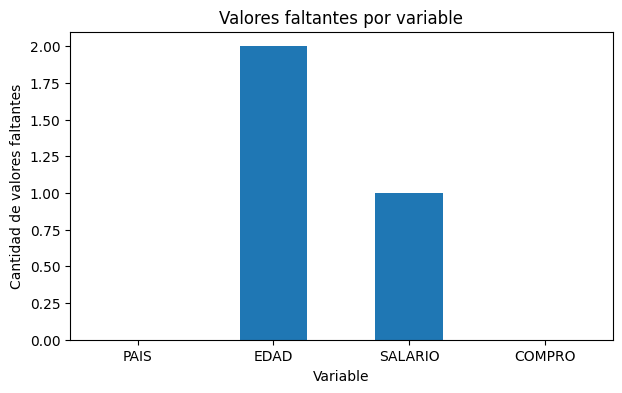

In [ ]:

fig, ax = plt.subplots(figsize=(7, 4))
dataset.isna().sum().plot(kind="bar", ax=ax)
ax.set_title("Valores faltantes por variable")
ax.set_ylabel("Cantidad de valores faltantes")
ax.set_xlabel("Variable")
plt.xticks(rotation=0)
plt.show()



## 3. Separar variables predictoras `X` y variable objetivo `y`

Siguiendo las diapositivas:

- `X` contiene `PAIS`, `EDAD` y `SALARIO`.
- `y` contiene `COMPRO`.


In [ ]:

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

print("X:")
print(X)

print("\ny:")
print(y)


X:
[['COLOMBIA' 37.0 800000.0]
 ['PERU' 45.0 900000.0]
 ['ECUADOR' 28.0 300000.0]
 ['BOLIVIA' 23.0 400000.0]
 ['COLOMBIA' 56.0 200000.0]
 ['PERU' 34.0 nan]
 ['ECUADOR' 25.0 500000.0]
 ['BOLIVIA' nan 600000.0]
 ['COLOMBIA' 14.0 300000.0]
 ['PERU' 18.0 200000.0]
 ['ECUADOR' nan 700000.0]
 ['BOLIVIA' 19.0 450000.0]]

y:
['SI' 'SI' 'SI' 'NO' 'NO' 'NO' 'NO' 'SI' 'SI' 'SI' 'SI' 'NO']



## 4. Imputación de valores faltantes

En las diapositivas se usa `SimpleImputer` con la estrategia de la **media** para las columnas numéricas.

La media sustituye los valores ausentes de:

- `EDAD`
- `SALARIO`


In [ ]:

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=np.nan, strategy="mean")

# Columnas 1 y 2 de X: EDAD y SALARIO
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

print("Datos después de imputar:")
print(X)


Datos después de imputar:
[['COLOMBIA' 37.0 800000.0]
 ['PERU' 45.0 900000.0]
 ['ECUADOR' 28.0 300000.0]
 ['BOLIVIA' 23.0 400000.0]
 ['COLOMBIA' 56.0 200000.0]
 ['PERU' 34.0 486363.63636363635]
 ['ECUADOR' 25.0 500000.0]
 ['BOLIVIA' 29.9 600000.0]
 ['COLOMBIA' 14.0 300000.0]
 ['PERU' 18.0 200000.0]
 ['ECUADOR' 29.9 700000.0]
 ['BOLIVIA' 19.0 450000.0]]


In [ ]:

print("Medias utilizadas para imputar:")
print(f"EDAD    : {imputer.statistics_[0]:.2f}")
print(f"SALARIO : {imputer.statistics_[1]:,.2f}")


Medias utilizadas para imputar:
EDAD    : 29.90
SALARIO : 486,363.64



En este conjunto:

- La edad faltante se reemplaza por aproximadamente **29.9**.
- El salario faltante se reemplaza por aproximadamente **486,363.64**.

Esto reproduce el resultado mostrado en las diapositivas.


## 5. Crear un DataFrame limpio

In [ ]:

df_limpio = pd.DataFrame(X, columns=["pais", "edad", "salario"])
df_limpio["compro"] = y

# Aseguramos tipos numéricos
df_limpio["edad"] = pd.to_numeric(df_limpio["edad"])
df_limpio["salario"] = pd.to_numeric(df_limpio["salario"])

print("--- DATOS CON VALORES FALTANTES IMPUTADOS ---")
display(df_limpio)


--- DATOS CON VALORES FALTANTES IMPUTADOS ---


,pais,edad,salario,compro
0,COLOMBIA,37.00,"800,000.00",SI
1,PERU,45.00,"900,000.00",SI
2,ECUADOR,28.00,"300,000.00",SI
3,BOLIVIA,23.00,"400,000.00",NO
4,COLOMBIA,56.00,"200,000.00",NO
5,PERU,34.00,"486,363.64",NO
6,ECUADOR,25.00,"500,000.00",NO
7,BOLIVIA,29.90,"600,000.00",SI
8,COLOMBIA,14.00,"300,000.00",SI
9,PERU,18.00,"200,000.00",SI


In [ ]:

print("Valores faltantes después de imputar:")
print(df_limpio.isna().sum())


Valores faltantes después de imputar:
pais       0
edad       0
salario    0
compro     0
dtype: int64



## 6. Variables categóricas y variables dummy

Una variable categórica representa grupos o etiquetas, por ejemplo:

- `pais`: COLOMBIA, PERU, ECUADOR, BOLIVIA.
- `compro`: SI, NO.

Los modelos de Machine Learning normalmente necesitan entradas numéricas. Por eso transformamos las categorías a columnas binarias mediante **One-Hot Encoding**.

Usaremos `pd.get_dummies(..., drop_first=True)` como en las diapositivas.


In [ ]:

df_codificado = pd.get_dummies(
    df_limpio,
    columns=["pais", "compro"],
    drop_first=True
)

# Convertir columnas booleanas a 0 y 1
for col in df_codificado.columns:
    if df_codificado[col].dtype == "bool":
        df_codificado[col] = df_codificado[col].astype(int)

print("--- DATOS CODIFICADOS (SIN REORDENAR) ---")
display(df_codificado)


--- DATOS CODIFICADOS (SIN REORDENAR) ---


,edad,salario,pais_COLOMBIA,pais_ECUADOR,pais_PERU,compro_SI
0,37.00,"800,000.00",1,0,0,1
1,45.00,"900,000.00",0,0,1,1
2,28.00,"300,000.00",0,1,0,1
3,23.00,"400,000.00",0,0,0,0
4,56.00,"200,000.00",1,0,0,0
5,34.00,"486,363.64",0,0,1,0
6,25.00,"500,000.00",0,1,0,0
7,29.90,"600,000.00",0,0,0,1
8,14.00,"300,000.00",1,0,0,1
9,18.00,"200,000.00",0,0,1,1



### ¿Por qué `drop_first=True`?

Si una variable tiene `k` categorías, con `drop_first=True` conservamos `k-1` columnas dummy.

Para `PAIS`, una categoría funciona como referencia. En este caso, **BOLIVIA** queda representada cuando las tres columnas dummy de país valen 0.

Esto reduce redundancia entre columnas.


## 7. Reordenar columnas como en las diapositivas

In [ ]:

columnas_pais = [col for col in df_codificado.columns if col.startswith("pais_")]
columna_compro = "compro_SI"
columnas_numericas = ["edad", "salario"]

nuevo_orden = columnas_pais + columnas_numericas + [columna_compro]
df_codificado = df_codificado[nuevo_orden]

print("--- DATOS CODIFICADOS (compro_SI como última columna) ---")
display(df_codificado)


--- DATOS CODIFICADOS (compro_SI como última columna) ---


,pais_COLOMBIA,pais_ECUADOR,pais_PERU,edad,salario,compro_SI
0,1,0,0,37.00,"800,000.00",1
1,0,0,1,45.00,"900,000.00",1
2,0,1,0,28.00,"300,000.00",1
3,0,0,0,23.00,"400,000.00",0
4,1,0,0,56.00,"200,000.00",0
5,0,0,1,34.00,"486,363.64",0
6,0,1,0,25.00,"500,000.00",0
7,0,0,0,29.90,"600,000.00",1
8,1,0,0,14.00,"300,000.00",1
9,0,0,1,18.00,"200,000.00",1


## 8. Verificar la estructura final

In [ ]:

print("--- ESTRUCTURA FINAL DEL DATAFRAME ---")
print(f"Total de filas    : {df_codificado.shape[0]}")
print(f"Total de columnas : {df_codificado.shape[1]}")
print(f"Columnas en orden : {list(df_codificado.columns)}")
print("\nValores faltantes:")
print(df_codificado.isna().sum())


--- ESTRUCTURA FINAL DEL DATAFRAME ---
Total de filas    : 12
Total de columnas : 6
Columnas en orden : ['pais_COLOMBIA', 'pais_ECUADOR', 'pais_PERU', 'edad', 'salario', 'compro_SI']

Valores faltantes:
pais_COLOMBIA    0
pais_ECUADOR     0
pais_PERU        0
edad             0
salario          0
compro_SI        0
dtype: int64


## 9. Guardar el resultado

In [ ]:

nombre_archivo = "DATOS1_CODIFICADO.csv"
df_codificado.to_csv(nombre_archivo, index=False)

print(f"✅ Archivo guardado como '{nombre_archivo}'")


✅ Archivo guardado como 'DATOS1_CODIFICADO.csv'


In [ ]:

# Si ejecutas el notebook en Google Colab, esta celda permite descargar el CSV.
try:
    from google.colab import files
    files.download("DATOS1_CODIFICADO.csv")
except ImportError:
    print("Esta descarga automática funciona en Google Colab.")



# ⭐ Contenido adicional recomendado

Las siguientes secciones amplían las diapositivas con buenas prácticas de Machine Learning.



## 10. Buena práctica: evitar *data leakage*

En las diapositivas se imputa y codifica **antes** de separar entrenamiento y prueba, lo cual es útil para aprender cada transformación por separado.

Sin embargo, en un proyecto real conviene:

1. Separar primero entrenamiento y prueba.
2. Ajustar (`fit`) el imputador y el codificador **solo con entrenamiento**.
3. Aplicar (`transform`) esas mismas transformaciones a prueba.

Así evitamos que información del conjunto de prueba influya indirectamente en el entrenamiento.

La forma más segura de hacerlo es mediante un `Pipeline` y un `ColumnTransformer`.


In [ ]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

X_raw = dataset[["PAIS", "EDAD", "SALARIO"]].copy()
y_raw = dataset["COMPRO"].copy()

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="mean"))
            ]),
            ["EDAD", "SALARIO"]
        ),
        (
            "categoricas",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            ["PAIS"]
        )
    ]
)

print("Preprocesador definido.")
print("En el Notebook 2 lo utilizaremos después de separar train/test.")


Preprocesador definido.
En el Notebook 2 lo utilizaremos después de separar train/test.



## 11. Mini ejercicios

1. Cambia la estrategia de imputación de `mean` a `median`. ¿Qué valores cambian?
2. Ejecuta `pd.get_dummies(..., drop_first=False)`. ¿Cuántas columnas de país aparecen?
3. Agrega una nueva fila con un salario faltante y comprueba la imputación.
4. Investiga la diferencia entre:
   - One-Hot Encoding
   - Label Encoding
5. ¿Por qué `PAIS` no debería transformarse directamente en números como `COLOMBIA=1`, `PERU=2`, etc.?



## ✅ Resumen

En este notebook realizamos el flujo:

**Datos crudos → inspección → separación X/y → imputación → variables dummy → reordenamiento → validación → exportación**

El resultado queda listo para continuar con el **Notebook 2: Separando los Datos**.
